In [2]:
import pandas as pd

In [3]:
df = pd.read_csv("cleaned_apple_products_pricing.csv")

In [4]:
df["Date"] =pd.to_datetime(df["Date"])

In [5]:
df.head()

,Date,Platform,Product_Category,Model_Name,Condition,Launch_Price_USD,Launch_Price_INR,Current_Price_USD,Current_Price_INR,Discount_Pct,Sale_Event,Stock_Status,Rating,Reviews_Count
0,2020-09-19,Flipkart,Watch,Apple Watch Series 6 (44mm),New,429,42042,435.81,43322.41,0.0,No_Sale_Event,In Stock,4.7,40
1,2020-09-20,Flipkart,Watch,Apple Watch Series 6 (44mm),New,429,42042,436.49,42320.43,0.0,No_Sale_Event,Out of Stock,4.6,84
2,2020-09-23,Amazon,Watch,Apple Watch Series 6 (44mm),New,429,42042,422.73,40879.36,1.5,No_Sale_Event,In Stock,4.4,110
3,2020-09-23,Amazon,Watch,Apple Watch Series 6 (44mm),New,429,42042,425.00,42008.70,0.9,No_Sale_Event,In Stock,4.8,111
4,2020-09-24,Amazon,Watch,Apple Watch Series 6 (44mm),New,429,42042,436.22,41984.28,0.0,No_Sale_Event,In Stock,4.7,35


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80000 entries, 0 to 79999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Date               80000 non-null  datetime64[ns]
 1   Platform           80000 non-null  object        
 2   Product_Category   80000 non-null  object        
 3   Model_Name         80000 non-null  object        
 4   Condition          80000 non-null  object        
 5   Launch_Price_USD   80000 non-null  int64         
 6   Launch_Price_INR   80000 non-null  int64         
 7   Current_Price_USD  80000 non-null  float64       
 8   Current_Price_INR  80000 non-null  float64       
 9   Discount_Pct       80000 non-null  float64       
 10  Sale_Event         80000 non-null  object        
 11  Stock_Status       80000 non-null  object        
 12  Rating             80000 non-null  float64       
 13  Reviews_Count      80000 non-null  int64         
dtypes: dat

In [7]:
df.shape

(80000, 14)

In [8]:
df.isnull().sum()

Date                 0
Platform             0
Product_Category     0
Model_Name           0
Condition            0
Launch_Price_USD     0
Launch_Price_INR     0
Current_Price_USD    0
Current_Price_INR    0
Discount_Pct         0
Sale_Event           0
Stock_Status         0
Rating               0
Reviews_Count        0
dtype: int64

### Summary statistics

In [9]:
df[["Launch_Price_USD","Launch_Price_INR","Current_Price_USD"]].describe()

,Launch_Price_USD,Launch_Price_INR,Current_Price_USD
count,80000.000000,80000.000000,80000.000000
mean,963.959125,94467.994250,782.769855
std,470.086413,46068.468464,461.673970
min,329.000000,32242.000000,109.930000
25%,599.000000,58702.000000,432.930000
50%,799.000000,78302.000000,699.740000
75%,1199.000000,117502.000000,989.112500
max,1999.000000,195902.000000,2038.970000


In [10]:
import matplotlib.pyplot as plt

#### Launch Price (USD)

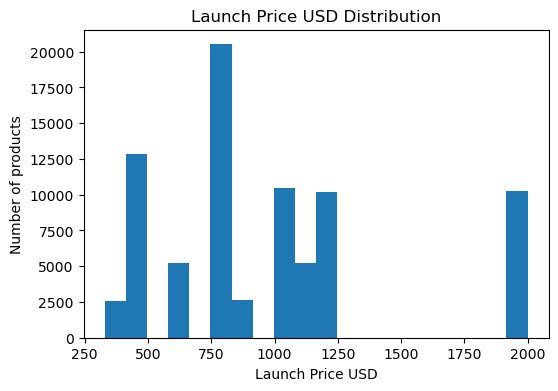

In [11]:
plt.figure(figsize = (6,4))
plt.hist(df["Launch_Price_USD"],bins = 20)
plt.title("Launch Price USD Distribution")
plt.xlabel("Launch Price USD")
plt.ylabel("Number of products")
plt.show()

### Observation
- Most products have a launch price between 400 and 1200
- A small number of premium products are priced around $2000
- The distribution indicates that Apple offers products across budget , mid-range, and premium price segments.
- There is a high launch price is 750

#### Launch Price (INR)

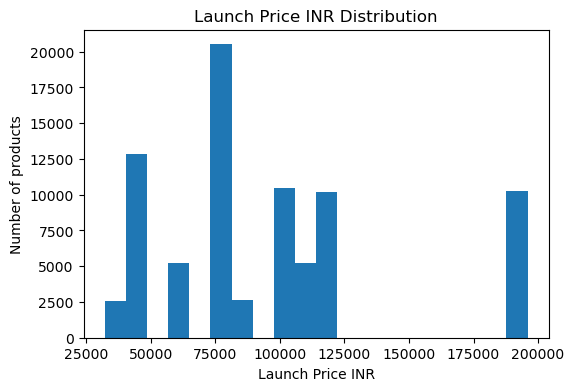

In [12]:
plt.figure(figsize = (6,4))
plt.hist(df["Launch_Price_INR"],bins = 20)
plt.title("Launch Price INR Distribution")
plt.xlabel("Launch Price INR")
plt.ylabel("Number of products")
plt.show()

#### Observation
- Most products have high a launch price between 40,000 and 1,20,000
- A fewer premium products are priced close to 2,00,000
- The INR distribution has the same shape as the USD because it is obtained by converting USD prices using a fixed exchange rate. 

#### Current price (USD)

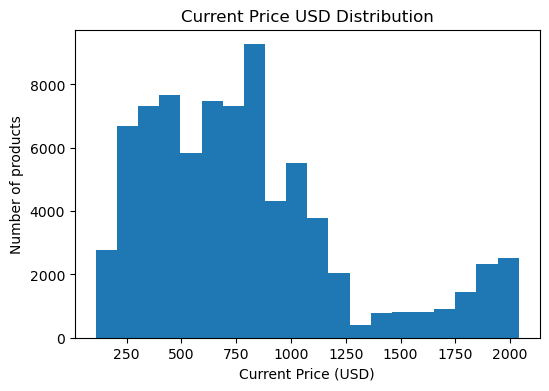

In [13]:
plt.figure(figsize=(6,4))
plt.hist(df["Current_Price_USD"],bins=20)
plt.title("Current Price USD Distribution")
plt.xlabel("Current Price (USD)")
plt.ylabel("Number of products")
plt.show()

### Observation
- Most apple products have a current price between 300 USD nad 1100 USD
- There are fewer premium products between 1500 USD and 2100 USD
- The distribution is right-skewed indicating that high-priced products are less common 

### Segment analysis by Product category and Stock status

In [15]:
df.groupby("Product_Category")[["Launch_Price_USD", "Current_Price_USD"]].mean().round(2)

,Launch_Price_USD,Current_Price_USD
Product_Category,,
Mac,1612.31,1382.49
Watch,533.32,398.64
iPad,749.82,573.08
iPhone,940.69,758.67


In [17]:
df.groupby("Stock_Status")[["Launch_Price_USD", "Current_Price_USD"]].mean().round(2)

,Launch_Price_USD,Current_Price_USD
Stock_Status,,
In Stock,978.23,819.92
Low Stock,934.54,708.52
Out of Stock,930.77,694.37


### Derive Date features

In [19]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Month_Name"] = df["Date"].dt.month_name()
df["Quarter"] =df["Date"].dt.quarter
df["Day"] = df["Date"].dt.day
df["Day_Name"] = df["Date"].dt.day_name()

In [21]:
df[["Date", "Year", "Month", "Month_Name", "Quarter", "Day", "Day_Name"]].head()

,Date,Year,Month,Month_Name,Quarter,Day,Day_Name
0,2020-09-19,2020,9,September,3,19,Saturday
1,2020-09-20,2020,9,September,3,20,Sunday
2,2020-09-23,2020,9,September,3,23,Wednesday
3,2020-09-23,2020,9,September,3,23,Wednesday
4,2020-09-24,2020,9,September,3,24,Thursday


In [23]:
df.to_csv("cleaned_and_updated_apple_products_pricing.csv", index = False)

In [24]:
print("Dataset updated successfully")

Dataset updated successfully
